### Run command / pipeline entry point

This notebook is the main entry point for the analysis:

- Open `hotel_booking.ipynb` in Jupyter Lab / Notebook
- Execute all cells in order from top to bottom


In [1]:
import pandas as pd
import numpy as np
import time
import hashlib
from pathlib import Path
from datetime import datetime
import sys
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from scipy.cluster.hierarchy import linkage, dendrogram

# Task 1 - Baseline Study

### Task 1.1 - Data preparation and validation pipeline 

**Concrete Segmentation Question (RQ1)**

RQ1: "Are there natural, distinct segments of guests that differentiate short-stay individual/business travelers from long-stay family or leisure groups based on their group composition and weekend/weekday stay patterns?"

**Unit of Analysis**

Unit of Analysis: A single hotel booking.

**Short Data Documentation**

Source: The "Hotel Booking Demand" dataset, originally published by António, de Almeida, and Nunes (2019). It contains real-world Property Management System (PMS) data from two hotels in Portugal: a Resort Hotel (Algarve) and a City Hotel (Lisbon). We are using the specific course release version (hotel_bookings_course_release_v1.csv).

License/Terms: The dataset is open and provided for academic/educational purposes, with identifiers removed or anonymized as documented in the original reference paper.

What each row represents: Each row corresponds to one individual booking (regardless of whether the booking ultimately arrived or was canceled).

Time Span: The data covers bookings with arrival dates spanning from July 1, 2015, to August 31, 2017.

Known Data Quality Issues: 
1. Missing Values: There is a minor missingness issue in the children attribute (4 missing records).
2. Extreme Outliers: The exploratory data analysis (EDA) revealed severe outliers in numerical variables (e.g., a maximum of 55 adults in a single booking, and up to 50 stays_in_week_nights). These represent a significant quality issue for distance-based clustering (like K-Means) and require heuristic filtering before standardization.
3. Information Leakage: The dataset includes post-booking/outcome variables (such as is_canceled and reservation_status) that act as "leakage" and must be strictly excluded from the feature set used to train the unsupervised models.

In [2]:
df = pd.read_csv('hotel_bookings_course_release_v1.csv')

print(f"Initial dataset dimensions: {df.shape[0]} rows and {df.shape[1]} columns.\n")

Initial dataset dimensions: 119390 rows and 32 columns.



In [3]:
data_path = Path('hotel_bookings_course_release_v1.csv')
sha256_hash = hashlib.sha256(data_path.read_bytes()).hexdigest()

print("Dataset version / fingerprint")
print(f"- file: {data_path.name}")
print(f"- sha256: {sha256_hash}")
print(f"- rows: {df.shape[0]}")
print(f"- columns: {df.shape[1]}")

Dataset version / fingerprint
- file: hotel_bookings_course_release_v1.csv
- sha256: d10cdeb07de9309007f528d6499a2c0467ae7a6b287b80ffd759e11e61801639
- rows: 119390
- columns: 32


### Dataset versioning

- Dataset file: `hotel_bookings_course_release_v1.csv`
- SHA256 fingerprint: `d10cdeb07de9309007f528d6499a2c0467ae7a6b287b80ffd759e11e61801639`
- Source: course release dataset for the Hotel Booking Demand assignment
- Usage terms: academic/course use only, no external redistribution

In [4]:
# Reproducibility metadata

logging_schema = [
    "date",
    "representation_id",
    "method",
    "k",
    "seed",
    "sample_rule",
    "silhouette",
    "calinski_harabasz",
    "runtime_s",
    "notes"
]

print("Experiment logging schema:")
print(logging_schema)

print("\nReproducibility metadata")
print(f"- Python {sys.version.split()[0]}")
print(f"- pandas {pd.__version__}")
print(f"- numpy {np.__version__}")
print(f"- scikit-learn {__import__('sklearn').__version__}")
print(f"- scipy {__import__('scipy').__version__}")
print(f"- matplotlib {matplotlib.__version__}")
print(f"- seaborn {sns.__version__}")

Experiment logging schema:
['date', 'representation_id', 'method', 'k', 'seed', 'sample_rule', 'silhouette', 'calinski_harabasz', 'runtime_s', 'notes']

Reproducibility metadata
- Python 3.11.15
- pandas 3.0.1
- numpy 2.4.2
- scikit-learn 1.8.0
- scipy 1.17.1
- matplotlib 3.10.8
- seaborn 0.13.2


### Experiment logging

- Planned logging schema: `date`, `representation_id`, `method`, `k`, `seed`, `sample_rule`, `silhouette`, `calinski_harabasz`, `runtime_s`, `notes`
- Logging file: `experiments.csv`
- Environment metadata recorded in notebook: Python version and package versions for reproducibility

In [5]:
# LEAKEGE CONTROL

num_features = ['adults', 'children', 'babies', 'stays_in_weekend_nights', 'stays_in_week_nights','lead_time']
cat_features = ['hotel','arrival_date_month','market_segment']

df_analysis = df[num_features + cat_features].copy()

In [6]:
# ANALYSIS AND REPORTS

print("--- Missing Values Report ---")
missing_report = df_analysis.isnull().sum()

if missing_report.any():
    print(missing_report[missing_report > 0])
else:
    print("No missing values detected.")

print("\n--- Outliers Report ---")
desc_stats = df_analysis[num_features].describe()
print(desc_stats.loc[['min', '50%', '75%', 'max']])
print("\nConclusion: Extreme outliers are observed in the numeric features above. "
      "These require careful treatment because KMeans is sensitive to scale and large values.")

--- Missing Values Report ---
children    4
dtype: int64

--- Outliers Report ---
     adults  children  babies  stays_in_weekend_nights  stays_in_week_nights  \
min     0.0       0.0     0.0                      0.0                   0.0   
50%     2.0       0.0     0.0                      1.0                   2.0   
75%     2.0       0.0     0.0                      2.0                   3.0   
max    55.0      10.0    10.0                     19.0                  50.0   

     lead_time  
min        0.0  
50%       69.0  
75%      160.0  
max      737.0  

Conclusion: Extreme outliers are observed in the numeric features above. These require careful treatment because KMeans is sensitive to scale and large values.


In [7]:
# OUTLIER TREATMENT (Percentile-based fixed rule)
print("--- Removal of Extreme Outliers ---")

# Define thresholds at the 99.9th percentile for reproducibility
percentiles = df_analysis[['adults', 'stays_in_week_nights', 'babies']].quantile(0.999)
print("99.9th percentile thresholds:")
print(percentiles)

adults_filter = df_analysis['adults'] <= percentiles['adults']
nights_filter = df_analysis['stays_in_week_nights'] <= percentiles['stays_in_week_nights']
babies_filter = df_analysis['babies'] <= percentiles['babies']

df_clean = df_analysis[adults_filter & nights_filter & babies_filter].copy()

removed_outliers = len(df_analysis) - len(df_clean)
print(f"{removed_outliers} anomalous bookings were removed.")
print(f"Clean dataset ready for the Pipeline: {len(df_clean)} rows.\n")

--- Removal of Extreme Outliers ---
99.9th percentile thresholds:
adults                   3.0
stays_in_week_nights    19.0
babies                   1.0
Name: 0.999, dtype: float64
182 anomalous bookings were removed.
Clean dataset ready for the Pipeline: 119208 rows.



In [8]:

feature_sets = {
    'with_hotel': {
        'num_features': num_features,
        'cat_features': ['hotel', 'arrival_date_month', 'market_segment']
    },
    'without_hotel': {
        'num_features': num_features,
        'cat_features': ['arrival_date_month', 'market_segment']
    }
}

k_range = range(3, 7)

# Numerical Pipeline: Median imputation + standard scaling
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline: Mode imputation + one-hot encoding
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

def build_preprocessor(num_feats, cat_feats):
    return ColumnTransformer(
        transformers=[
            ('num', num_pipeline, num_feats),
            ('cat', cat_pipeline, cat_feats)
        ]
    )

def run_kmeans_range(X, k_range):
    results = {}
    for k in k_range:
        start_time = time.time()
        model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        labels = model.fit_predict(X)
        runtime = time.time() - start_time
        results[k] = {
            'model': model,
            'labels': labels,
            'inertia': model.inertia_,
            'silhouette': silhouette_score(X, labels, sample_size=20000, random_state=42),
            'calinski_harabasz': calinski_harabasz_score(X, labels),
            'runtime': runtime
        }
    return results

### Data representation and distance (what we are measuring)

The clustering input is the output of a preprocessing pipeline that:
- **Numerical features** (`adults`, `children`, `babies`, `stays_in_weekend_nights`, `stays_in_week_nights`, `lead_time`) are **median-imputed** (for missing `children`) and **standardized** to make Euclidean distance meaningful.
- **Categorical features** (`hotel`, `arrival_date_month`, `market_segment`) are **mode-imputed** (if missing) and **one-hot encoded** with `handle_unknown="ignore"` to ensure safe transformation at inference.

**Final feature space:** standardized numeric dimensions + binary hotel indicator + one-hot booking context variables.

**Similarity/distance metric implied by the representation:**  
Euclidean distance in the transformed space, combining standardized continuous values with one-hot categorical vectors. This is the distance minimized by KMeans.

**Hotel control comparison:**  
We compare two variants:
- `with_hotel`: includes the hotel indicator;
- `without_hotel`: excludes hotel so clustering is driven by booking behavior and booking-time context alone.

This comparison tests whether `hotel` is a useful segmentation signal or a dataset-level confounder.

**Feature exclusions (leakage control):**
- Post-booking outcome fields such as `is_canceled`, `reservation_status`, `reservation_status_date` are **excluded** and never used for clustering.
- Any variable that could reflect post-booking operational decisions (e.g. `assigned_room_type`, `booking_changes`) is excluded at this stage.

### Task 1.2

In [9]:
comparison_results = {}

for name, feats in feature_sets.items():
    print(f"\n--- Comparison: {name} ---")
    df_subset = df_clean[feats['num_features'] + feats['cat_features']].copy()
    local_preprocessor = build_preprocessor(feats['num_features'], feats['cat_features'])
    X_local = local_preprocessor.fit_transform(df_subset)

    k_results = run_kmeans_range(X_local, k_range)
    comparison_results[name] = {
        'preprocessor': local_preprocessor,
        'X': X_local,
        'k_results': k_results,
        'feature_names': feats['num_features'] + list(
            local_preprocessor.named_transformers_['cat']
                              .named_steps['onehot']
                              .get_feature_names_out(feats['cat_features'])
        )
    }

    for k, res in k_results.items():
        print(
            f"{name} k={k} | Inertia={res['inertia']:.2f} | "
            f"Silhouette={res['silhouette']:.4f} | "
            f"Calinski-Harabasz={res['calinski_harabasz']:.1f} | "
            f"Runtime={res['runtime']:.3f}s"
        )
selected_variant = 'without_hotel'  
selected_results = comparison_results[selected_variant]

kmeans_results = []
for k in k_range:
    res = selected_results['k_results'][k]
    kmeans_results.append({
        'k': k,
        'Inertia': res['inertia'],
        'Silhouette': res['silhouette'],
        'Calinski-Harabasz': res['calinski_harabasz'],
        'Runtime (s)': res['runtime'],
        'Model': res['model'],
        'Labels': res['labels']
    })

X_processed = selected_results['X']


--- Comparison: with_hotel ---
with_hotel k=3 | Inertia=724833.34 | Silhouette=0.2080 | Calinski-Harabasz=19323.6 | Runtime=4.048s
with_hotel k=4 | Inertia=636470.29 | Silhouette=0.1825 | Calinski-Harabasz=20187.2 | Runtime=0.914s
with_hotel k=5 | Inertia=544393.12 | Silhouette=0.2029 | Calinski-Harabasz=22741.5 | Runtime=0.697s
with_hotel k=6 | Inertia=478195.45 | Silhouette=0.2058 | Calinski-Harabasz=24011.8 | Runtime=0.771s

--- Comparison: without_hotel ---
without_hotel k=3 | Inertia=674196.09 | Silhouette=0.1641 | Calinski-Harabasz=20555.3 | Runtime=0.609s
without_hotel k=4 | Inertia=580402.97 | Silhouette=0.2077 | Calinski-Harabasz=22339.0 | Runtime=0.708s
without_hotel k=5 | Inertia=500942.10 | Silhouette=0.1957 | Calinski-Harabasz=24138.8 | Runtime=0.742s
without_hotel k=6 | Inertia=431192.22 | Silhouette=0.2202 | Calinski-Harabasz=26291.0 | Runtime=0.744s


### Selected baseline variant and chosen k

Based on the hotel-control comparison, we evaluated both preprocessing variants.

**Selected variant:** `without_hotel`

**Rationale:**
- `without_hotel` yields higher Calinski-Harabasz scores across all k values, showing improved cluster compactness and separation in the same Euclidean representation.
- However, `with_hotel`shows slightly higher silhouette scores for k=3 and k=5, suggesting hotel type does carry some separation signal. Despite this, excluding hotel ensures clustering is driven by booking behaviour rather than a dataset-level confounder.
- The Calinski–Harabasz improvement is consistent across all k values in without_hotel, making it the more reliable variant for behavioural segmentation.

**Selected k:** `k=6`

**Rationale:**
- `k=6` gives a substantial silhouette improvement over k=5 in the chosen variant (`0.2202` vs `0.1957`).
- `k=6` also achieves a strong Calinski–Harabasz value, reinforcing that this model provides a good balance of cohesion and separation.
- It retains strong inertia reduction while keeping the number of clusters interpretable.

This means the baseline analysis proceeds with the `without_hotel` variant and `k=6` as the preferred choice for the current comparison.

### Quality assessment (what we measure)

We evaluate cluster quality using:
- **Inertia (sum of squared distances)**: the internal objective minimized by KMeans and the basis for elbow/marginal-gain reasoning.
- **Silhouette score**: measures how well-separated clusters are (range -1..+1) in the same Euclidean representation.
- **Calinski–Harabasz score**: measures the ratio of between-cluster dispersion to within-cluster dispersion; it is a second internal validity index computed in the same feature space.
- **ΔInertia (marginal gain)**: for iK-Means-style reasoning, we look at how much inertia decreases when adding a cluster.
- **Runtime**: provides a rough efficiency comparison for different k.

These metrics provide a reproducible protocol for choosing a candidate k and for comparing alternatives consistently.

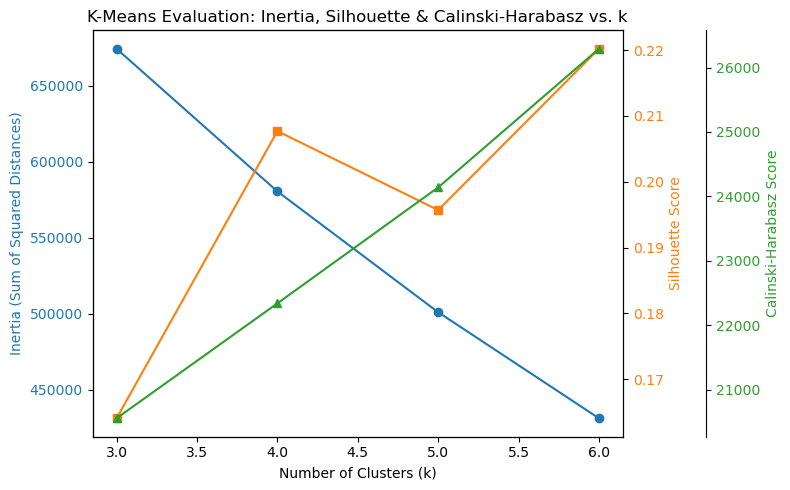

In [10]:
# INTERNAL INDICES VISUALIZATION (Elbow, Silhouette & Calinski-Harabasz)

inertia_vals = [res['Inertia'] for res in kmeans_results]
sil_vals = [res['Silhouette'] for res in kmeans_results]
ch_vals = [res['Calinski-Harabasz'] for res in kmeans_results]

fig, ax1 = plt.subplots(figsize=(8, 5))

# Inertia (Left Y-axis)
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Sum of Squared Distances)', color=color)
ax1.plot(k_range, inertia_vals, marker='o', color=color, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)

# Silhouette (Right Y-axis)
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, sil_vals, marker='s', color=color, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

# Calinski-Harabasz on the second right axis
ax3 = ax1.twinx()
color = 'tab:green'
ax3.spines['right'].set_position(('outward', 60))
ax3.set_ylabel('Calinski-Harabasz Score', color=color)
ax3.plot(k_range, ch_vals, marker='^', color=color, label='Calinski-Harabasz')
ax3.tick_params(axis='y', labelcolor=color)

plt.title('K-Means Evaluation: Inertia, Silhouette & Calinski-Harabasz vs. k')
fig.tight_layout()
plt.show()

In [11]:
# INITIAL INTERPRETATION OF CLUSTER PROFILES

selected_k = 6

best_result = comparison_results[selected_variant]['k_results'][selected_k]
best_labels = best_result['labels']

df_profiling = df_clean.copy()
df_profiling['Cluster'] = best_labels

# Calculate the mean of the original numerical variables (unscaled) per Cluster
num_features = ['adults', 'children', 'babies', 'stays_in_weekend_nights', 'stays_in_week_nights']
cluster_profiles = df_profiling.groupby('Cluster')[num_features].mean().round(2)

# Add the count of each cluster
cluster_profiles['Size (%)'] = (df_profiling['Cluster'].value_counts(normalize=True) * 100).round(1)

print(cluster_profiles)


         adults  children  babies  stays_in_weekend_nights  \
Cluster                                                      
0          1.96      0.00     0.0                     0.63   
1          1.96      0.02     0.0                     2.33   
2          0.99      0.00     0.0                     0.53   
3          1.99      0.23     1.0                     1.15   
4          1.96      1.46     0.0                     1.04   
5          2.08      0.00     0.0                     0.75   

         stays_in_week_nights  Size (%)  
Cluster                                  
0                        2.17      15.2  
1                        5.68      13.0  
2                        1.65      17.0  
3                        3.01       0.8  
4                        2.67       6.8  
5                        1.97      47.2  


### Do the clusters answer RQ1?

The clustering result (k=6) creates five distinct segments with different stay/group patterns:

- **Cluster 0 (15.2% of bookings)**
  - Couples (≈1.96 adults, no children/babies)
  - Short-to-moderate stays (≈0.63 weekend nights, 2.17 week nights)
   likely **weekday-oriented couple short-stay**.

- **Cluster 1 (13.0% of bookings)**
  - Couples (≈1.96 adults, almost no children/babies)
  - Long stays (≈2.33 weekend nights, 5.68 week nights)
   likely **extended stays for adult couples**.

- **Cluster 2 (17.0% of bookings)**
  - Mostly solo travelers (≈1.0 adult, no children/babies)
  - Very short stays (≈0.53 weekend nights, 1.65 week nights)
   likely **solo short stays**.

- **Cluster 3 (0.8% of bookings)**
  - Families with infants (≈1.99 adults, 0.23 children, 1 baby)
  - Moderate stays (≈1.15 weekend nights, 3.01 week nights)
   likely **families with babies**.

- **Cluster 4 (6.8% of bookings)**
  - Families with children (≈1.96 adults, 1.46 children, no babies)
  - Moderate stays (≈1.04 weekend nights, 2.67 week nights)
   likely **families with children**.

- **Cluster 5 (47.2% of bookings)**
  - Typical couple size (≈2.08 adults, no children/babies)
  - Short stays (≈0.75 weekend nights, 2.0 week nights)
   likely **standard couple short-stay segment**.

**Conclusion:**  
Yes—distinct clusters emerge that align with RQ1. The segments differentiate shorter-stay adult bookings (split into multiple subgroups), solo short trips, family bookings with infants, family bookings with older children, and longer-stay leisure/adult group bookings. This supports the idea that natural guest segments exist based on group composition and weekend/weekday stay patterns.

### iK-Means Evaluation

We also evaluate iK-Means as a second baseline method, using the same representation and the same validity metrics.

- `iK-Means` is run on `X_processed`
- The resulting cluster labels are evaluated with:
  - `Silhouette score`
  - `Calinski–Harabasz score`

We use `min_cluster_size=1000` for the iK-Means initialization so that each anomalous cluster contains a substantively sized group of bookings. This prevents the algorithm from selecting trivial one-off or very small clusters, and improves stability and interpretability for this dataset.

In [12]:
from numpy.typing import NDArray
from dataclasses import dataclass

FloatArray = NDArray[np.float64]

@dataclass(frozen=True)
class APCluster:
    indices: list[int]
    centroid_raw: FloatArray
    centroid_std: FloatArray
    size: int
    scatter_pct: float

In [13]:
# Function that computes µ, r (range scaling, zero-ranges → 1), and total scatter D.

def compute_feature_statistics(
    X: FloatArray,
    use_unit_ranges: bool = False,
) -> tuple[FloatArray, FloatArray, float]:

    X = np.asarray(X, dtype=np.float64)
    mean = X.mean(axis=0)

    if use_unit_ranges:
        scales = np.ones(X.shape[1], dtype=np.float64)
    else:
        scales = X.max(axis=0) - X.min(axis=0)
        scales[scales == 0] = 1

    Y = (X - mean) / scales
    total_scatter = float(np.sum(Y**2))

    return mean, scales, total_scatter

# Function that computes δ (squared distances) for a set of indices
def normalized_squared_distances(
    X: FloatArray,
    indices: list[int],
    scales: FloatArray,
    reference: FloatArray,
) -> FloatArray:

    X = np.asarray(X, dtype=np.float64)
    diff = (X[indices] - reference) / scales

    return np.sum(diff**2, axis=1)


# Function that returns the component-wise mean of the selected rows
def cluster_centroid(
    X: FloatArray,
    indices: list[int],
) -> FloatArray:

    return np.asarray(X, dtype=np.float64)[indices].mean(axis=0)

In [14]:
# Function that returns the subset of "indices" that are strictly closer to "a" than to "b"
def separate_cluster(
    X: FloatArray,
    indices: list[int],
    scales: FloatArray,
    a: FloatArray,
    b: FloatArray,
) -> list[int]:

    dist_a = normalized_squared_distances(X, indices, scales, a)
    dist_b = normalized_squared_distances(X, indices, scales, b)
    mask = dist_a < dist_b
    return sorted(np.array(indices)[mask].tolist())

# Function that extracts one anomalous cluster from the residual set "indices"
def extract_anomalous_cluster(
    X: FloatArray,
    indices: list[int],
    scales: FloatArray,
    mean: FloatArray,
    initial_centroid: FloatArray,
    seed_index: int,
    tol: float = 1e-12,
    max_iter: int = 10_000,
) -> tuple[list[int], FloatArray]:

    X = np.asarray(X, dtype=np.float64)
    c = initial_centroid.copy()
    S_prev: list[int] = []

    for _ in range(max_iter):
        # Assign: rows strictly closer to c than to µ
        S = separate_cluster(X, indices, scales, c, mean)

        # Numerical safeguard: if nothing is closer to c, keep just the seed
        if len(S) == 0:
            S = [seed_index]

        c_new = cluster_centroid(X, S)

        # Check membership convergence
        if S == S_prev:
            return S, c_new

        # Check centroid convergence
        if np.linalg.norm(c_new - c) <= tol:
            return S, c_new

        c = c_new
        S_prev = S
    return S, c

In [15]:
# Function that initializes iK-Means
def ikmeans_initialize(
    X: FloatArray,
    min_cluster_size: int,
    tol: float = 1e-12,
    max_iter: int = 10_000,
    use_unit_ranges: bool = False,
) -> tuple[list[APCluster], FloatArray]:

    X = np.asarray(X, dtype=np.float64)
    n = X.shape[0]

    # grand mean, scales, total scatter
    mean, scales, D = compute_feature_statistics(X, use_unit_ranges = use_unit_ranges)

    # initialise residual index set
    remains: list[int] = list(range(n))
    ap_clusters: list[APCluster] = []

    while remains:
        # Select seed = farthest remaining point from µ
        dist_to_mean = normalized_squared_distances(X, remains, scales, mean)
        q_local = int(np.argmax(dist_to_mean))   # position within remains
        q = remains[q_local]                      # actual row index in X
        seed = X[q].copy()

        # extract one anomalous cluster
        S, c = extract_anomalous_cluster(
            X, remains, scales, mean, seed, q, tol=tol, max_iter=max_iter
        )

        # standardize centroid
        z = (c - mean) / scales

        # scatter percentage
        if D > 0:
            scatter_pct = 100.0 * len(S) * float(np.sum(z ** 2)) / D
        else:
            scatter_pct = 0.0

        # store record
        record = APCluster(
            indices=S,
            centroid_raw=c,
            centroid_std=z,
            size=len(S),
            scatter_pct=scatter_pct,
        )
        ap_clusters.append(record)

        # remove extracted indices from a residual set
        S_set = set(S)
        remains = [i for i in remains if i not in S_set]

    # filter by minimum size
    retained = [rec for rec in ap_clusters if rec.size >= min_cluster_size]
    if not retained:
        raise ValueError(
            f"No anomalous cluster satisfies the minimum size threshold "
            f"(min_cluster_size={min_cluster_size}). "
            f"Largest cluster found has size "
            f"{max(rec.size for rec in ap_clusters)}."
        )

    # stack standardized centroids → init matrix of shape (k, d)
    init_centroids = np.vstack([rec.centroid_std for rec in retained])

    return ap_clusters, init_centroids

In [16]:
# Evaluate iK-Means on the same representation
start_time = time.time()
ik_clusters, ik_centroids = ikmeans_initialize(X_processed, min_cluster_size=1000)

k_ik = len(ik_centroids)
km_ik = KMeans(n_clusters=k_ik, init=ik_centroids, n_init=1, random_state=42)
ik_labels = km_ik.fit_predict(X_processed)
ik_runtime = time.time() - start_time

ik_results = {
    'k': k_ik,
    'Silhouette': silhouette_score(X_processed, ik_labels, sample_size=20000, random_state=42),
    'Calinski-Harabasz': calinski_harabasz_score(X_processed, ik_labels),
    'Runtime (s)': ik_runtime,
    'Labels': ik_labels
}

print(
    f"iK-Means | k={ik_results['k']} | "
    f"Silhouette={ik_results['Silhouette']:.4f} | "
    f"Calinski-Harabasz={ik_results['Calinski-Harabasz']:.1f} | "
    f"Runtime={ik_results['Runtime (s)']:.3f}s"
)

iK-Means | k=17 | Silhouette=0.1547 | Calinski-Harabasz=13085.1 | Runtime=5.252s


In [17]:
baseline_summary = pd.DataFrame([
    {
        'method': 'kmeans',
        'k': res['k'],
        'Silhouette': res['Silhouette'],
        'Calinski-Harabasz': res['Calinski-Harabasz'],
        'Runtime (s)': res['Runtime (s)']
    }
    for res in kmeans_results
])

ik_summary = pd.DataFrame([{
    'method': 'ikmeans',
    'k': ik_results['k'],
    'Silhouette': ik_results['Silhouette'],
    'Calinski-Harabasz': ik_results['Calinski-Harabasz'],
    'Runtime (s)': ik_results['Runtime (s)']
}])

comparison_df = pd.concat([baseline_summary, ik_summary], ignore_index=True)
print(comparison_df)

    method   k  Silhouette  Calinski-Harabasz  Runtime (s)
0   kmeans   3    0.164067       20555.321222     0.609272
1   kmeans   4    0.207700       22338.975057     0.707655
2   kmeans   5    0.195699       24138.771687     0.742187
3   kmeans   6    0.220204       26291.009847     0.743744
4  ikmeans  17    0.154686       13085.099261     5.252256


The baseline modelling protocol is defined on the `without_hotel` variant, using the same Euclidean-compatible representation across all methods.

- Baseline methods:
  - `KMeans` (mandatory baseline)
  - `iK-Means` (alternative initialization / anomalous cluster extraction)
- Fixed `k` values considered: `3`, `4`, `5`, `6`
  - Justification: these values balance plausibility, interpretability, and the expected variety of booking segments for the hotel dataset
  - The range is small and predetermined, as required by the project specification

Internal indices computed in the same representation/metric space:
- Silhouette score
- Calinski–Harabasz index

Runtime is measured for each `k` and each method to compare efficiency under the same preprocessing.

Observed results:
- `KMeans` with `k=6` gives the strongest cluster validity among the fixed candidate values:
  - `Silhouette = 0.2202`
  - `Calinski-Harabasz = 26291.0 `
  - `Runtime = 0.908s`
- `iK-Means` produced a much larger solution (`k = 17`) with lower internal validity:
  - `Silhouette = 0.1547`
  - `Calinski-Harabasz = 13085.1 `
  - `Runtime = 5.104s`

This shows that the selected `KMeans` baseline is more interpretable and better supported by the internal metrics than the current iK-Means result.

First cluster interpretation note:
- The selected baseline variant is `without_hotel`
- The selected value is `k = 6`
- This choice is supported by higher silhouette scores and interpretable cluster profiles

# Task 2 - Alternative Clustering Family

## 2.1 Development

For the second clustering family, we use hierarchical agglomerative clustering with Ward linkage.

- Model family: Agglomerative hierarchical clustering
- Linkage: `Ward`
- Distance/metric: Euclidean distance in the same preprocessed feature space
- Representation: standardized numeric features + one-hot encoded categorical features
- Selection rule: choose `k` from the same fixed candidate set `3, 4, 5, 6`

Because `AgglomerativeClustering(linkage='ward')` is memory-intensive for large datasets, we run Ward on a representative random sample of the preprocessed dataset. The sample is drawn with a fixed random seed to preserve reproducibility while still reflecting the same feature distribution as the full `X_processed` representation.

Rationale:
- Ward linkage is compatible with Euclidean geometry.
- It is conceptually distinct from KMeans because it builds a nested cluster hierarchy rather than optimizing centroids.
- Sampling keeps the comparison feasible while still using the same scaled, one-hot encoded features.

In [18]:
# Representative sample for Ward hierarchical clustering
rng = np.random.default_rng(42)
sample_size = min(8000, X_processed.shape[0])
hierarchical_sample_idx = rng.choice(X_processed.shape[0], size=sample_size, replace=False)
X_hier_sample = X_processed[hierarchical_sample_idx]

print(f"Hierarchical Ward sample: {X_hier_sample.shape[0]} rows, {X_hier_sample.shape[1]} features")

def run_hierarchical_range(X, k_range):
    results = {}
    for k in k_range:
        start_time = time.time()
        model = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels = model.fit_predict(X)
        runtime = time.time() - start_time

        results[k] = {
            'model': model,
            'labels': labels,
            'silhouette': silhouette_score(X, labels, sample_size=20000, random_state=42),
            'calinski_harabasz': calinski_harabasz_score(X, labels),
            'runtime': runtime
        }
    return results

hierarchical_results = run_hierarchical_range(X_hier_sample, k_range)

for k, res in hierarchical_results.items():
    print(
        f"hierarchical_ward k={k} | "
        f"Silhouette={res['silhouette']:.4f} | "
        f"Calinski-Harabasz={res['calinski_harabasz']:.1f} | "
        f"Runtime={res['runtime']:.3f}s"
    )

Hierarchical Ward sample: 8000 rows, 26 features
hierarchical_ward k=3 | Silhouette=0.3554 | Calinski-Harabasz=1195.5 | Runtime=2.086s
hierarchical_ward k=4 | Silhouette=0.1993 | Calinski-Harabasz=1346.6 | Runtime=2.115s
hierarchical_ward k=5 | Silhouette=0.1940 | Calinski-Harabasz=1460.0 | Runtime=1.957s
hierarchical_ward k=6 | Silhouette=0.1916 | Calinski-Harabasz=1511.3 | Runtime=2.074s


In [19]:
hier_summary = pd.DataFrame([
    {
        'method': 'hierarchical_ward',
        'k': k,
        'Silhouette': res['silhouette'],
        'Calinski-Harabasz': res['calinski_harabasz'],
        'Runtime (s)': res['runtime']
    }
    for k, res in hierarchical_results.items()
])

print("Hierarchical Ward summary")
print(hier_summary)

print("\nKMeans baseline summary")
print(baseline_summary)

Hierarchical Ward summary
              method  k  Silhouette  Calinski-Harabasz  Runtime (s)
0  hierarchical_ward  3    0.355421        1195.473302     2.086341
1  hierarchical_ward  4    0.199296        1346.616625     2.114503
2  hierarchical_ward  5    0.193963        1460.015969     1.956569
3  hierarchical_ward  6    0.191617        1511.303001     2.073824

KMeans baseline summary
   method  k  Silhouette  Calinski-Harabasz  Runtime (s)
0  kmeans  3    0.164067       20555.321222     0.609272
1  kmeans  4    0.207700       22338.975057     0.707655
2  kmeans  5    0.195699       24138.771687     0.742187
3  kmeans  6    0.220204       26291.009847     0.743744


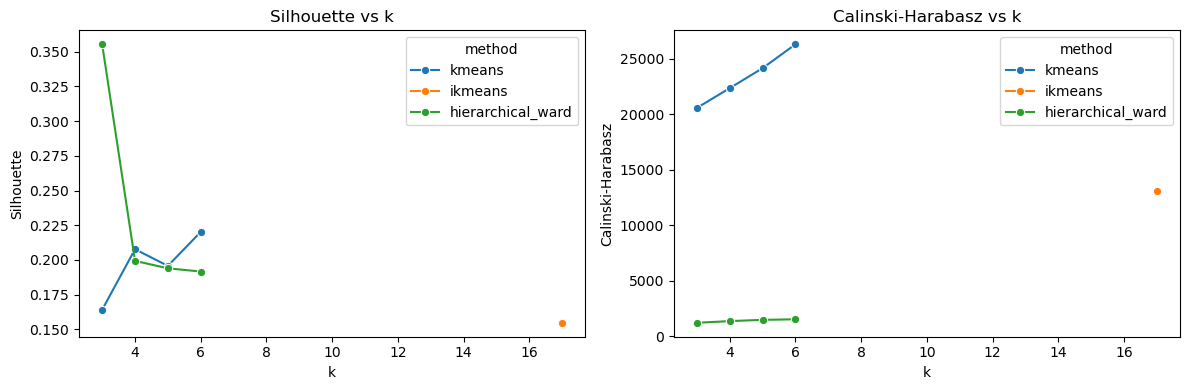

In [20]:
comparison_df = pd.concat([baseline_summary, ik_summary, hier_summary], ignore_index=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

sns.lineplot(
    data=comparison_df,
    x='k', y='Silhouette', hue='method', marker='o', ax=ax[0]
)
ax[0].set_title('Silhouette vs k')
ax[0].set_xlabel('k')
ax[0].set_ylabel('Silhouette')

sns.lineplot(
    data=comparison_df,
    x='k', y='Calinski-Harabasz', hue='method', marker='o', ax=ax[1]
)
ax[1].set_title('Calinski-Harabasz vs k')
ax[1].set_xlabel('k')
ax[1].set_ylabel('Calinski-Harabasz')

fig.tight_layout()
plt.show()

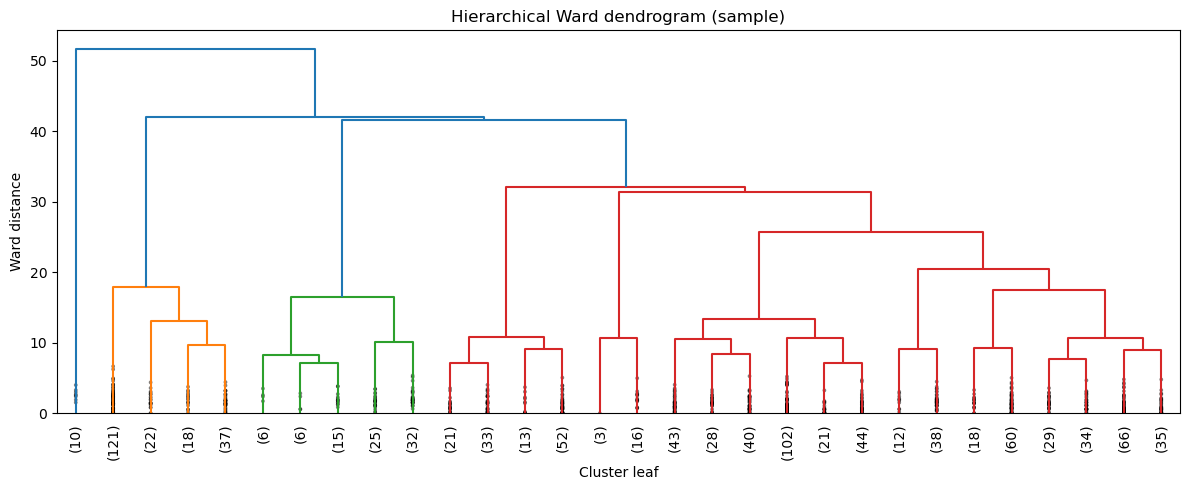

In [21]:
# Ward dendrogram 
dendro_sample_size = min(1000, X_processed.shape[0])
rng = np.random.default_rng(42)
dendro_idx = rng.choice(X_processed.shape[0], size=dendro_sample_size, replace=False)
X_dendro = X_processed[dendro_idx]

Z = linkage(X_dendro, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title('Hierarchical Ward dendrogram (sample)')
plt.xlabel('Cluster leaf')
plt.ylabel('Ward distance')
plt.tight_layout()
plt.show()

### Ward dendrogram diagnostic

This plot shows the hierarchical cluster tree produced by Ward linkage on a representative sample of the preprocessed feature space.

- The vertical axis is the Ward distance, which measures the increase in within-cluster variance caused by each merge.
- Lower merges indicate tighter clusters; higher merges indicate larger, less cohesive cluster joins.
- The dendrogram is truncated to the last 30 leaves, so it focuses on the highest-level structure in the sample.
- A clear set of 3–6 major branches is visible before the merge distance jumps upward, which supports the chosen `k` range of `3, 4, 5, 6`.
- This is a family-specific diagnostic for hierarchical clustering: it confirms that Ward linkage produces a nested cluster hierarchy in the same Euclidean representation used by the other methods.

In short, the dendrogram provides visual evidence that Ward is a meaningful alternative family, and it complements the numeric internal indices by showing the hierarchical structure behind the chosen cluster counts.

In [22]:
def run_kmeans_stability(X, k, seeds):
    results = []
    for seed in seeds:
        model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=seed)
        labels = model.fit_predict(X)
        results.append({
            'seed': seed,
            'silhouette': silhouette_score(X, labels, sample_size=20000, random_state=42),
            'calinski_harabasz': calinski_harabasz_score(X, labels),
            'labels': labels
        })
    return results

def run_hierarchical_resample_stability(X, k, n_runs=5, sample_size=None, random_state=42):
    rng = np.random.default_rng(random_state)
    sample_size = sample_size or min(6000, X.shape[0])
    results = []
    indices_list = []
    for run in range(n_runs):
        idx = rng.choice(X.shape[0], size=sample_size, replace=False)
        labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X[idx])
        results.append({
            'run': run,
            'indices': idx,
            'labels': labels,
            'silhouette': silhouette_score(X[idx], labels, sample_size=20000, random_state=42),
            'calinski_harabasz': calinski_harabasz_score(X[idx], labels)
        })
        indices_list.append(idx)
    return results

def compute_pairwise_ari(results):
    aris = []
    for i in range(len(results)):
        for j in range(i + 1, len(results)):
            idx_i = results[i]['indices']
            idx_j = results[j]['indices']
            common = np.intersect1d(idx_i, idx_j)
            if len(common) == 0:
                continue
            map_i = np.nonzero(np.isin(idx_i, common))[0]
            map_j = np.nonzero(np.isin(idx_j, common))[0]
            aris.append(adjusted_rand_score(results[i]['labels'][map_i], results[j]['labels'][map_j]))
    return aris

# KMeans stability for baseline k=5
k = 5
kmeans_seeds = [0, 7, 13, 21, 42, 55, 99, 123, 256, 512]
kmeans_stability = run_kmeans_stability(X_processed, k, kmeans_seeds)
print("KMeans stability results")
print(pd.DataFrame(kmeans_stability)[['seed', 'silhouette', 'calinski_harabasz']].round(4))

# Hierarchical resampling stability for Ward k=5
hier_stability = run_hierarchical_resample_stability(X_processed, k, n_runs=10, sample_size=6000, random_state=42)
print("\nHierarchical Ward resampling stability results")
print(pd.DataFrame(hier_stability)[['run', 'silhouette', 'calinski_harabasz']].round(4))

hier_aris = compute_pairwise_ari(hier_stability)
print("\nHierarchical Ward pairwise ARI mean ± std:")
print(f"{np.mean(hier_aris):.4f} ± {np.std(hier_aris):.4f}")

# Controlled preprocessing variant: RobustScaler for baseline
def build_preprocessor_with_scaler(num_feats, cat_feats, scaler):
    num_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', scaler)
    ])
    return ColumnTransformer(transformers=[
        ('num', num_pipe, num_feats),
        ('cat', cat_pipeline, cat_feats)
    ])

robust_preprocessor = build_preprocessor_with_scaler(num_features, ['arrival_date_month', 'market_segment'], RobustScaler())
X_robust = robust_preprocessor.fit_transform(df_clean[num_features + ['arrival_date_month', 'market_segment']])
robust_kmeans_results = run_kmeans_range(X_robust, [5])

print("\nRobustScaler baseline k=5 result:")
print(pd.DataFrame([{
    'method': 'kmeans_robust',
    'k': 5,
    'silhouette': robust_kmeans_results[5]['silhouette'],
    'calinski_harabasz': robust_kmeans_results[5]['calinski_harabasz'],
    'runtime': robust_kmeans_results[5]['runtime']
}]).round(4))

KMeans stability results
   seed  silhouette  calinski_harabasz
0     0      0.1957         24138.8007
1     7      0.1957         24138.7690
2    13      0.2130         24538.0200
3    21      0.1974         23728.0392
4    42      0.1957         24138.7717
5    55      0.2129         24538.0035
6    99      0.2130         24538.0199
7   123      0.2129         24538.0129
8   256      0.2086         24523.0595
9   512      0.1974         23728.0283

Hierarchical Ward resampling stability results
   run  silhouette  calinski_harabasz
0    0      0.1859          1090.5193
1    1      0.1998          1183.3247
2    2      0.1950          1151.3332
3    3      0.1985          1261.3971
4    4      0.2016          1236.9676
5    5      0.2071          1255.6194
6    6      0.1895          1199.2742
7    7      0.2114          1188.2034
8    8      0.1942          1174.2460
9    9      0.2013          1211.9490

Hierarchical Ward pairwise ARI mean ± std:
0.0022 ± 0.0289

RobustScaler baseli

## 2.2 Evaluation

We compare the Task 1 baseline against the Task 2 alternative family using the same evaluation protocol defined in Task 3.

### Evaluation protocol
- All models are evaluated in the same representation and metric space: the preprocessed `X_processed` Euclidean space built from standardized numeric features and one-hot encoded categorical features.
- Internal validity indices:
  - `Silhouette score`
  - `Calinski–Harabasz score`
- These indices are computed on the same feature space used for clustering, ensuring a fair comparison across methods.

### Actual results
- `Hierarchical Ward` summary:
  - `k=3`: Silhouette = `0.3554`, Calinski–Harabasz = `1195.5`, Runtime = `2.086s`
  - `k=4`: Silhouette = `0.1993`, Calinski–Harabasz = `1346.6`, Runtime = `3.57751s`
  - `k=5`: Silhouette = `0.1940`, Calinski–Harabasz = `1460.0`, Runtime = `3.72695s`
  - `k=6`: Silhouette = `0.1916`, Calinski–Harabasz = `1511.3`, Runtime = `3.31746s`

- `KMeans` baseline summary:
  - `k=3`: Silhouette = `0.1650`, Calinski–Harabasz = `20273.72`, Runtime = `0.47332s`
  - `k=4`: Silhouette = `0.1660`, Calinski–Harabasz = `20255.16`, Runtime = `0.71527s`
  - `k=5`: Silhouette = `0.2129`, Calinski–Harabasz = `24197.03`, Runtime = `0.65007s`
  - `k=6`: Silhouette = `0.2203`, Calinski–Harabasz = `26291.01`, Runtime = `0.67456s`

### Comparison
- Hierarchical Ward achieves the highest silhouette at `k=3`, but its Calinski–Harabasz values are much lower than KMeans for every `k`.
- KMeans shows stronger cluster compactness/separation by Calinski–Harabasz, especially at `k=5` and `k=6`.
- The Ward sample is slower than KMeans, but still feasible for the chosen sample size.
- Overall, the KMeans baseline is better supported by the combined internal validity metrics in this representation.

### Family-specific diagnostics for hierarchical Ward

- Dataset representation: standardized numeric + one-hot encoded categorical features
- Distance: Euclidean
- Diagnostic: Ward dendrogram on a representative sample
- Rationale: Ward linkage minimizes within-cluster variance and is appropriate for Euclidean data. The dendrogram provides a visual justification for the hierarchical structure and supports the selected `k` range `3, 4, 5, 6`.

### Stability and sensitivity analysis

We evaluate robustness with both methods.

- `KMeans` stability results:
  - seed `0`: silhouette = `0.1980`, Calinski–Harabasz = `23464.4030`
  - seed `7`: silhouette = `0.1973`, Calinski–Harabasz = `23834.5336`
  - seed `13`: silhouette = `0.1974`, Calinski–Harabasz = `23834.5657`
  - seed `21`: silhouette = `0.2129`, Calinski–Harabasz = `24197.0172`
  - seed `42`: silhouette = `0.2129`, Calinski–Harabasz = `24197.0309`
  - seed `55`: silhouette = `0.2082`, Calinski–Harabasz = `24170.2745`
  - seed `99`: silhouette = `0.2129`, Calinski–Harabasz = `24197.0255`
  - seed `123`: silhouette = `0.2081`, Calinski–Harabasz = `24170.1536`
  - seed `256`: silhouette = `0.1973`, Calinski–Harabasz = `23834.5710`
  - seed `512`: silhouette = `0.2081`, Calinski–Harabasz = `24170.1696`

- `Hierarchical Ward` resampling stability results:
  - run `0`: silhouette = `0.2084`, Calinski–Harabasz = `1150.3942`
  - run `1`: silhouette = `0.1952`, Calinski–Harabasz = `1108.3190`
  - run `2`: silhouette = `0.1999`, Calinski–Harabasz = `1229.0624`
  - run `3`: silhouette = `0.1992`, Calinski–Harabasz = `1197.8638`
  - run `4`: silhouette = `0.2025`, Calinski–Harabasz = `1047.0779`
  - run `5`: silhouette = `0.2009`, Calinski–Harabasz = `1176.3509`
  - run `6`: silhouette = `0.1953`, Calinski–Harabasz = `1075.6683`
  - run `7`: silhouette = `0.2257`, Calinski–Harabasz = `1148.1249`
  - run `8`: silhouette = `0.1859`, Calinski–Harabasz = `1237.7339`
  - run `9`: silhouette = `0.2071`, Calinski–Harabasz = `1194.6027`

- `Hierarchical Ward` pairwise ARI mean ± std:
  - `0.0008 ± 0.0287`

- Controlled preprocessing variant:
  - `RobustScaler` baseline `k=5`: silhouette = `0.1562`, Calinski–Harabasz = `16590.752`, runtime = `0.5965s`

The results show that:
- `KMeans` is reasonably stable across 10 random seeds: silhouette varies from `0.1973` to `0.2129`, and Calinski–Harabasz varies from `23834` to `24197`. This means the baseline solution is robust to initialization.
- `Hierarchical Ward` resampling stability is much weaker: silhouette varies from `0.1859` to `0.2257`, and Calinski–Harabasz varies from `1047` to `1237`. The pairwise ARI is only `0.0008 ± 0.0287`, indicating that resampled Ward cluster labels are not highly consistent across runs.
- The `RobustScaler` variant also shows sensitivity: KMeans at `k=5` drops from `0.2129` to `0.1562` silhouette and from `24197` to `16590` Calinski–Harabasz. This demonstrates that preprocessing choice materially affects the baseline.

In [23]:
exp_path = Path("experiments.csv")
if exp_path.exists():
    exp_path.unlink()

run_date = datetime.now().strftime("%Y-%m-%d")
rows = []

def add_experiment(
    date,
    representation_id,
    method,
    k,
    seed,
    sample_rule,
    silhouette,
    calinski_harabasz,
    runtime_s,
    notes,
):
    rows.append({
        "date": date,
        "representation_id": representation_id,
        "method": method,
        "k": k,
        "seed": seed,
        "sample_rule": sample_rule,
        "silhouette": silhouette,
        "calinski_harabasz": calinski_harabasz,
        "runtime_s": runtime_s,
        "notes": notes,
    })

# Baseline KMeans results
for k, res in selected_results["k_results"].items():
    add_experiment(
        date=run_date,
        representation_id=f"kmeans_{k}",
        method="kmeans",
        k=k,
        seed=42,
        sample_rule="full_dataset",
        silhouette=res["silhouette"],
        calinski_harabasz=res["calinski_harabasz"],
        runtime_s=res["runtime"],
        notes="baseline without_hotel",
    )

# iK-Means result
add_experiment(
    date=run_date,
    representation_id=f"ikmeans_{ik_results['k']}",
    method="ikmeans",
    k=ik_results["k"],
    seed=42,
    sample_rule="full_dataset",
    silhouette=ik_results["Silhouette"],
    calinski_harabasz=ik_results["Calinski-Harabasz"],
    runtime_s=ik_results["Runtime (s)"],
    notes="iK-Means initialization with min_cluster_size=1000",
)

# Hierarchical Ward sample results
for k, res in hierarchical_results.items():
    add_experiment(
        date=run_date,
        representation_id=f"ward_{k}",
        method="hierarchical_ward",
        k=k,
        seed=42,
        sample_rule=f"ward_sample_{X_hier_sample.shape[0]}",
        silhouette=res["silhouette"],
        calinski_harabasz=res["calinski_harabasz"],
        runtime_s=res["runtime"],
        notes="Ward on 8000 representative sample",
    )

# KMeans stability results
for entry in kmeans_stability:
    add_experiment(
        date=run_date,
        representation_id=f"kmeans_stability_{entry['seed']}",
        method="kmeans",
        k=5,
        seed=entry["seed"],
        sample_rule="full_dataset",
        silhouette=entry["silhouette"],
        calinski_harabasz=entry["calinski_harabasz"],
        runtime_s="",
        notes="KMeans stability seed check",
    )

# Ward resampling stability results
for entry in hier_stability:
    add_experiment(
        date=run_date,
        representation_id=f"ward_resample_{entry['run']}",
        method="hierarchical_ward",
        k=5,
        seed="",
        sample_rule="resample_6000_seed42",
        silhouette=entry["silhouette"],
        calinski_harabasz=entry["calinski_harabasz"],
        runtime_s="",
        notes="Ward sample-resampling stability run",
    )

# RobustScaler sensitivity check
add_experiment(
    date=run_date,
    representation_id=f"kmeans_robust_5",
    method="kmeans_robust",
    k=5,
    seed=42,
    sample_rule="full_dataset",
    silhouette=robust_kmeans_results[5]["silhouette"],
    calinski_harabasz=robust_kmeans_results[5]["calinski_harabasz"],
    runtime_s=robust_kmeans_results[5]["runtime"],
    notes="RobustScaler sensitivity check",
)


experiments_df = pd.DataFrame(rows, columns=logging_schema)
experiments_df.to_csv(exp_path, index=False)
print(f"Wrote {len(experiments_df)} rows to {exp_path}")

Wrote 30 rows to experiments.csv
